In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import copy
import gymnasium as gym
from tqdm import tqdm
import sys
sys.path.insert(0, "../src/")
from Network import *
from inputFuc import *
from plotting import *
from utilsRL import *
from IPython.display import display, clear_output
import time
import imageio

In [2]:
data_config = dict(default_data_config)
general_config = dict(default_general_config)
train_config = dict(default_train_config)

general_config['save_path'] = "../saved_models/Cartpole/"

#### With P learning ###
dt = general_config["dt"]

# init both teacher and student net
batch = train_config["batch_size"]
general_config["device"] = "cuda" if torch.cuda.is_available() else "cpu"
device = general_config["device"]
print(device)

env = CartPoleCustomize(obs='velocity')

n_actions = env.env.action_space.n.item()
# Get the number of state observations
obs, info = env.reset()
n_observations = obs.shape[-1]

actor_config = dict(default_model_config)
critic_config = dict(default_model_config)
actor_config['n_in'] = n_observations
critic_config['n_in'] = n_observations
actor_config['n_out'] = n_actions
critic_config['n_out'] = 1

cpu


# Train from scratch

In [3]:
def episode_interpolate(env, actor, critic, critic_target, optimizer_actor, optimizer_critic):
    # Run one episode
    observation, _ = env.reset()
    actor.reset()
    critic.reset()
    critic_target.reset()
    device = actor.device

    terminated, truncated = False, False
    total_reward=0
    lamd = 0.9
    gamma = 0.99 # are they different?
    rwd_scale = 0.2

    interpolate = 2
    interp_k = torch.linspace(0, 1, interpolate)
    observations = observation[None,:, :].repeat(interpolate, 1, 1)
    observations = observations.to(device)
    delta_rec = 0

    action_step = 0.02

    with torch.no_grad():
        t = 0
        while not terminated and not truncated:
            # Take a random action
            for k in range(1, interpolate):
                u, _ = actor.step(observations[k])
                value,_ = critic.step(observations[k])

            p = torch.softmax(u, dim=1)
            action = np.random.choice(n_actions, p=p[0].cpu().numpy())

            # Step the environment
            observation_next, reward, terminated, truncated,_ = env.step(action)
            reward *= rwd_scale

            observations = observation[None, :, :] + interp_k[:, None, None] * (observation_next - observation)[None, :,  :]

            for k in range(1, interpolate):
                value_next,_ = critic_target.step(observations[k])

            delta = reward + gamma*value_next - value
            delta = delta.to(device)
            delta_rec += torch.abs(delta)
            delta = torch.clamp(delta, -0.015, 0.015)
            actor.prop(F.one_hot(torch.tensor(action), num_classes=n_actions).to(device)-p)
            actor.backwardsRL(delta.item(), lamd)            
            critic.prop(1.)
            critic.backwardsRL(delta.item(), lamd)

            observation = observation_next
            total_reward+=reward

            t += 1
            # if t%200 == 0:
            #     torch.nn.utils.clip_grad_norm_(actor.parameters(), 1.0)
            #     torch.nn.utils.clip_grad_norm_(critic.parameters(), 1.0)
            #     optimizer_actor.step()
            #     optimizer_critic.step()
            #     optimizer_actor.zero_grad(set_to_none=False)
            #     optimizer_critic.zero_grad(set_to_none=False)
            #     soft_update(critic_target, critic, tau = 0.02)

        torch.nn.utils.clip_grad_norm_(actor.parameters(), 1.0)
        torch.nn.utils.clip_grad_norm_(critic.parameters(), 1.0)
        optimizer_actor.step()
        optimizer_critic.step()
        optimizer_actor.zero_grad(set_to_none=False)
        optimizer_critic.zero_grad(set_to_none=False)
        soft_update(critic_target, critic, tau = 0.05)      

    return total_reward/rwd_scale, t*action_step, delta_rec/t

In [4]:
#Change schedular, add temporatue?
actor = buildRLNet(actor_config, general_config).to(device)
critic = buildRLNet(critic_config, general_config).to(device)
critic_target = buildRLNet(critic_config, general_config).to(device)
for p in critic_target.parameters():
    p.requires_grad = False
hard_update(critic_target, critic)

num_episode = 4000

optimizer_actor = torch.optim.Adam(
    actor.parameters(),
    lr=1e-4, #4e-4,
    betas=(0.9, 0.999)
)

optimizer_critic = torch.optim.Adam(
    critic.parameters(),
    lr=2e-3,#5e-3,
    betas=(0.9, 0.999)
)

scheduler_actor = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_actor,
    T_max = num_episode,
)

scheduler_critic = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_critic,
    T_max = num_episode,
)

# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer,
#     mode='max',        # reward should increase
#     factor=0.5,
#     patience=20,
#     threshold=5,
#     min_lr=1e-6
# )


In [5]:
# Create the CartPole environment
R_avg, duration_avg, delta_avg = 8, 0, 0
best_R, best_duration = 0, 0
R_rec, delta_rec = [], []
for i in range(num_episode):
    total_reward, duration, delta = episode_interpolate(env, actor, critic, critic_target, optimizer_actor, optimizer_critic)
    #scheduler_actor.step()
    #scheduler_critic.step()
    if total_reward < R_avg:
        actor.beta *= 0.997
        critic.beta *= 0.997
    else:
        actor.beta += 0.001#*= 1.001
        critic.beta += 0.001#*= 1.001
    R_avg = 0.995*R_avg + 0.005*total_reward
    duration_avg = 0.998*duration_avg + 0.002*duration
    delta_avg = 0.999*delta_avg + 0.001*delta
    if i%100==99:
        R_rec.append(R_avg)
        print(f"Reward: {R_avg:.2f}, Duration: {duration_avg:.2f}s, delta: {delta_avg.item():.3f}, {actor.beta:.3f}")
        if R_avg > best_R:
            best_R = R_avg
            best_actor_state = actor.state_dict().copy()
            best_critic_state = critic.state_dict().copy()


env.close() # Close the environment
print("finished")

if best_R > 400:
    torch.save(best_actor_state, general_config['save_path']+"actor%d.ckp"%int(best_R))
    torch.save(best_critic_state, general_config['save_path']+"critic%d.ckp"%int(best_R))

Reward: 9.88, Duration: 0.06s, delta: 0.007, 1.027
Reward: 12.92, Duration: 0.14s, delta: 0.016, 1.033
Reward: 34.87, Duration: 0.42s, delta: 0.025, 1.120
Reward: 74.38, Duration: 0.94s, delta: 0.032, 1.189
Reward: 105.80, Duration: 1.43s, delta: 0.036, 1.207
Reward: 152.09, Duration: 2.14s, delta: 0.040, 1.246
Reward: 203.74, Duration: 2.95s, delta: 0.043, 1.293
Reward: 255.74, Duration: 3.83s, delta: 0.046, 1.328
Reward: 292.64, Duration: 4.57s, delta: 0.047, 1.333
Reward: 320.40, Duration: 5.22s, delta: 0.048, 1.290
Reward: 348.86, Duration: 5.85s, delta: 0.050, 1.260
Reward: 384.80, Duration: 6.53s, delta: 0.050, 1.292
Reward: 411.78, Duration: 7.10s, delta: 0.050, 1.323
Reward: 436.16, Duration: 7.60s, delta: 0.049, 1.377
Reward: 454.52, Duration: 8.03s, delta: 0.048, 1.426
Reward: 468.43, Duration: 8.38s, delta: 0.047, 1.472
Reward: 478.65, Duration: 8.68s, delta: 0.045, 1.528
Reward: 484.74, Duration: 8.92s, delta: 0.043, 1.572


KeyboardInterrupt: 

# Adaptation and visulize

In [140]:
def episode_interpolate_adapt(env, actor, critic, critic_target, 
                              optimizer_actor, optimizer_critic,
                              adapt=False, visualize=False,):
    # Run one episode
    observation, _ = env.reset()
    actor.reset()
    critic.reset()
    critic_target.reset()

    terminated, truncated = False, False
    total_reward=0
    gamma=0.9

    interpolate = 2
    interp_k = torch.linspace(0, 1, interpolate)
    observations = observation[None,:, :].repeat(interpolate, 1, 1)

    action_step = 20 #ms
    if visualize:
        plt.figure(figsize=(5,4))
    frames = []

    with torch.no_grad():
        t = 0
        while not terminated and t<1000:
            # Take a random action
            for k in range(1, interpolate):
                u, _ = actor.step(observations[k])
                value,_ = critic.step(observations[k])

            p = torch.softmax(u, dim=1)
            action = np.random.choice(n_actions, p=p[0].cpu().numpy())

            # Step the environment
            observation_next, reward, terminated, truncated,_ = env.step(action)
            frame = env.render()
            frames.append(frame)
            if visualize:
                plt.imshow(frame)
                plt.axis("off")
                display(plt.gcf())
                clear_output(wait=True)

            observations = observation[None, :, :] + interp_k[:, None, None] * (observation_next - observation)[None, :,  :]

            for k in range(1, interpolate):
                value_next,_ = critic_target.step(observations[k])

            delta = reward + gamma*value_next - value

            if adapt:
                actor.prop(F.one_hot(torch.tensor(action), num_classes=n_actions)-p)
                actor.backwardsRL(delta.item(), gamma)
                critic.prop(1.)
                critic.backwardsRL(delta.item(), gamma)

            observation = observation_next
            total_reward+=reward

            t+=1
            if t%50==0 and adapt:
                optimizer_actor.step()
                optimizer_critic.step()
                optimizer_actor.zero_grad(set_to_none=False)
                optimizer_critic.zero_grad(set_to_none=False)
            if t%100==0 and adapt:
                hard_update(critic_target, critic)

        if adapt:
            optimizer_actor.step()
            optimizer_critic.step()
            optimizer_actor.zero_grad(set_to_none=False)
            optimizer_critic.zero_grad(set_to_none=False)
            

    return total_reward, frames

In [150]:
num_trials = 200
wind = 7.

visualize = True if num_trials<=2 else False
env = WindCartPoleEnv(wind=wind, render_mode="rgb_array")
env = CartPoleCustomize(env=env)  #Do we need time limit?
#env = CartPoleCustomize(env=None, display = True)
actor_state_dict = torch.load(general_config['save_path']+"actor496.ckp", weights_only=True)
critic_state_dict = torch.load(general_config['save_path']+"critic496.ckp", weights_only=True)

actor = buildRLNet(actor_config, general_config).to(device)
critic = buildRLNet(critic_config, general_config).to(device)
critic_target = buildRLNet(critic_config, general_config).to(device)

In [151]:
#Without online adpation
noAdapt_reward = []
actor.load_state_dict(actor_state_dict)
critic.load_state_dict(critic_state_dict)
critic_target.load_state_dict(critic_state_dict)

optimizer_actor = torch.optim.Adam(actor.parameters(), lr=0.)
optimizer_critic = torch.optim.Adam(critic.parameters(), lr=0.,)

for i in range(num_trials):
    total_reward, frames = episode_interpolate_adapt(env, actor, critic, critic_target,
                                                     optimizer_actor, optimizer_critic,
                                                     adapt=False, visualize=visualize,)
    noAdapt_reward.append(total_reward)
    if total_reward <0:
        imageio.mimsave("../Figures/cartpole_noAdapt%.1f.gif"%total_reward, frames, fps=30)

noAdapt_reward = np.array(noAdapt_reward)
print("Average Reward without adaptation: ", noAdapt_reward.mean())

Average Reward without adaptation:  142.32901


In [157]:
#With online adpation
Adapt_reward = []
for i in range(num_trials):
    actor.load_state_dict(actor_state_dict)
    critic.load_state_dict(critic_state_dict)
    critic_target.load_state_dict(critic_state_dict)
    
    # optimizer_actor = torch.optim.Adam(
    #     actor.parameters(),
    #     lr=2e-4,
    #     betas=(0.9, 0.99)
    # )
    
    # optimizer_critic = torch.optim.Adam(
    #     critic.parameters(),
    #     lr=2e-3,
    #     betas=(0.9, 0.99)
    # )

    actor_optimizer  = torch.optim.SGD(actor.parameters(), lr=1e-4)
    critic_optimizer = torch.optim.SGD(critic.parameters(), lr=2e-3)

    # actor_optimizer = torch.optim.RMSprop(
    #     actor.parameters(),
    #     lr=5e-5,
    #     alpha=0.99
    # )
    
    # critic_optimizer = torch.optim.RMSprop(
    #     critic.parameters(),
    #     lr=2e-3,
    #     alpha=0.99
    # )
    
    total_reward, frames = episode_interpolate_adapt(env, actor, critic, critic_target,
                                                     optimizer_actor, optimizer_critic,
                                                     adapt=True, visualize=visualize,)
    Adapt_reward.append(total_reward)
    if total_reward >700:
        imageio.mimsave("../Figures/cartpole_Adapt%.1f.gif"%total_reward, frames, fps=30)
Adapt_reward = np.array(Adapt_reward)
print("Average Reward with adaptation: ", Adapt_reward.mean())

Average Reward with adaptation:  123.96383


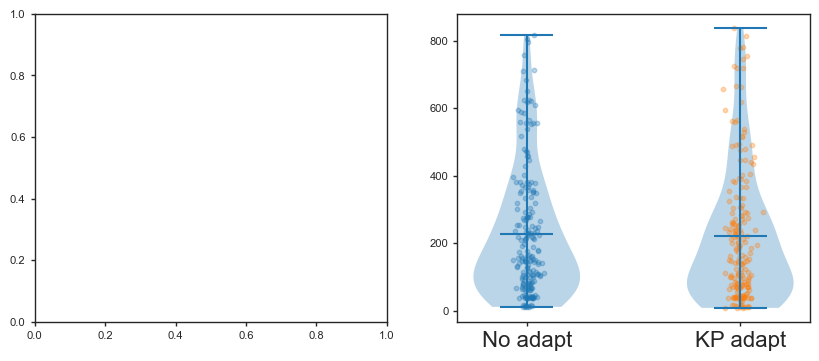

In [147]:
#TODO plot the bar with many runs
fig, axs = plt.subplots(1, 2, figsize = (10, 4))

data = [noAdapt_reward, Adapt_reward]
axs[1].violinplot(data, positions=[0,1], showmeans=True)
axs[1].set_xticks([0,1], ['No adapt', 'KP adapt'], fontsize=16)

for i, d in enumerate(data):
    x = np.random.normal(i, 0.03, size=len(d))  # small horizontal jitter
    axs[1].scatter(x, d, alpha=0.3, s=10)

#plt.savefig('./fig/LinRegCf%s.png'%activation)
plt.show()

In [ ]:
#TODO multi-episode learn, faster than BPTT?